# Section 1: Bayesian Estimation of a User Ability Parameter from Item Responses

## Task 1: Visualizing the Mechanics
The 2PL Item Response probability function is defined as:
$$p_i(\theta) = \frac{1}{1 + e^{-a_i(\theta - b_i)}}$$

**Interpretation of Shifting $b_i$:** Moving the difficulty parameter $b_i$ shifts the item response curve horizontally along the $\theta$-axis. Increasing $b_i$ shifts the curve to the right, meaning a higher latent ability level ($\theta$) is required to achieve a $50\%$ probability of answering the item correctly ($p_i(b_i) = 0.5$).

## Task 2: Sequential Likelihood Contribution
* **Single Likelihood Contribution ($L(y_k \mid \theta)$):**
  $$L(y_k \mid \theta) = [p_k(\theta)]^{y_k} [1 - p_k(\theta)]^{1 - y_k}$$

* **Joint Likelihood Function ($L(\mathbf{y}^{(k)} \mid \theta)$):**
  $$L(\mathbf{y}^{(k)} \mid \theta) = \prod_{i=1}^{k} [p_i(\theta)]^{y_i} [1 - p_i(\theta)]^{1 - y_i}$$

## Task 3: Mathematical Formulation of the Running Update
The recursive posterior update at step $k$ given the previous state and new observation $y_k$ is:
$$f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)}) \propto [p_k(\theta)]^{y_k} [1 - p_k(\theta)]^{1 - y_k} \cdot f_{\Theta \mid \mathbf{Y}^{(k-1)}}(\theta \mid \mathbf{y}^{(k-1)})$$

## Task 4: Dynamic Shifting
When a user correctly answers ($y_k = 1$) a highly difficult item (large $b_k$), the likelihood function $p_k(\theta)$ places high probability mass on higher values of $\theta$. Multiplying the previous posterior $f(\theta \mid \mathbf{y}^{(k-1)})$ by this likelihood function pulls and shifts the peak (mode/MAP estimate) of the new posterior density distribution towards higher positive $\theta$ values.

## Task 5: Tracking Certainty and Sharpness
The discrimination parameter $a_k$ determines the steepness (slope) of the item response probability curve near $\theta = b_k$.
* **Very Large $a_k$:** The likelihood curve drops off steeply away from the threshold, injecting high informational certainty. This drastically sharpens (narrows the variance of) the posterior density curve.
* **Very Small $a_k$:** The likelihood curve is nearly flat across the domain, adding very little new information and leaving the variance/sharpness of the posterior density curve largely unchanged.

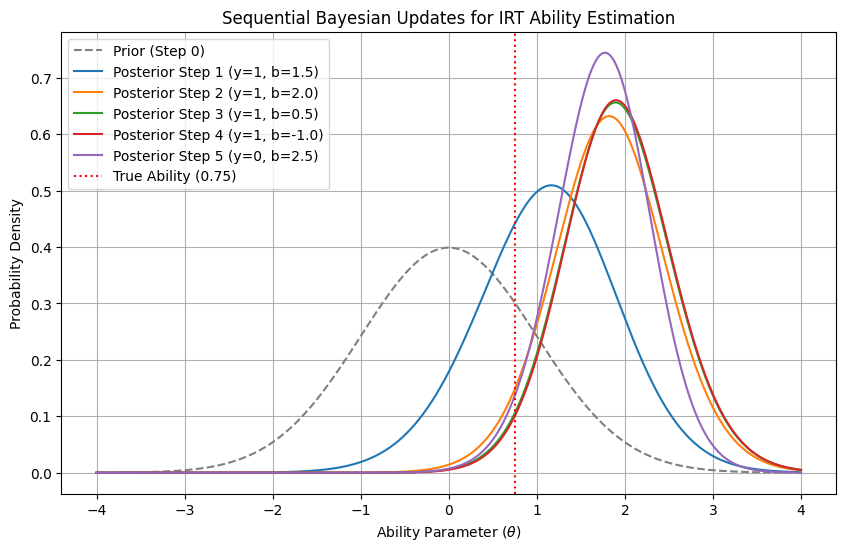

Bayes Means over steps: [np.float64(1.116556972787391), np.float64(1.824178281970481), np.float64(1.914939553412459), np.float64(1.925572268804029), np.float64(1.7449895073450485)]
MAP Estimates over steps: [np.float64(1.165165165165165), np.float64(1.821821821821822), np.float64(1.8938938938938943), np.float64(1.9019019019019021), np.float64(1.7737737737737733)]


In [1]:
# Task 6 & 7: Numerical Implementation and Evaluation
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Grid Domain
theta_grid = np.linspace(-4, 4, 1000)

# 2. Prior Initialization
prior = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * theta_grid**2)
prior /= np.trapezoid(prior, theta_grid)

# Simulated Dataset: (difficulty b_i, discrimination a_i, response y_i)
items = [
    {'b': 1.5, 'a': 1.8, 'y': 1},
    {'b': 2.0, 'a': 2.0, 'y': 1},
    {'b': 0.5, 'a': 1.2, 'y': 1},
    {'b': -1.0, 'a': 1.5, 'y': 1},
    {'b': 2.5, 'a': 2.2, 'y': 0}
]

posterior = prior.copy()
bayes_means = []
map_estimates = []

plt.figure(figsize=(10, 6))
plt.plot(theta_grid, prior, label="Prior (Step 0)", linestyle="--", color="gray")

for k, item in enumerate(items, 1):
    a, b, y = item['a'], item['b'], item['y']
    # Item response probability
    p = 1 / (1 + np.exp(-a * (theta_grid - b)))
    # Likelihood
    likelihood = (p**y) * ((1 - p)**(1 - y))

    # Update and Normalize
    unnorm_post = posterior * likelihood
    posterior = unnorm_post / np.trapezoid(unnorm_post, theta_grid)

    # Point Estimates
    mean_est = np.trapezoid(theta_grid * posterior, theta_grid)
    map_est = theta_grid[np.argmax(posterior)]

    bayes_means.append(mean_est)
    map_estimates.append(map_est)

    plt.plot(theta_grid, posterior, label=f"Posterior Step {k} (y={y}, b={b})")

plt.axvline(0.75, color='red', linestyle=':', label='True Ability (0.75)')
plt.title("Sequential Bayesian Updates for IRT Ability Estimation")
plt.xlabel(r"Ability Parameter ($\theta$)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

print("Bayes Means over steps:", bayes_means)
print("MAP Estimates over steps:", map_estimates)

# Section 2: Bayesian Tracking of Click-Through Rates (CTR) via Conjugate Beta-Binomial Updates

## Task 1: Structural Probability and Properties
* **Uninformative:** $\text{Beta}(1,1)$ produces a uniform flat line over $[0,1]$.
* **Right-skewed:** $\text{Beta}(2,8)$ concentrates density toward $0$ ($\alpha < \beta$).
* **Left-skewed:** $\text{Beta}(8,2)$ concentrates density toward $1$ ($\alpha > \beta$).
* **Interpretation:** $\alpha$ acts as pseudo-counts of clicks and $\beta$ as pseudo-counts of non-clicks. Increasing $\alpha$ shifts the center of mass toward $1$, while increasing $\beta$ shifts it toward $0$.

## Task 2: Sequential Likelihood and Joint History
* **Single Response Likelihood:** $L(y_k \mid \theta) = \theta^{y_k}(1-\theta)^{1-y_k}$
* **Joint Likelihood:** $L(\mathbf{y}^{(k)} \mid \theta) = \theta^{C_k} (1-\theta)^{k - C_k}$, where $C_k = \sum_{i=1}^k y_i$ is total clicks.

## Task 3: Closed-Form Analytical Updates (Conjugacy)
Given prior $\text{Beta}(\alpha_{k-1}, \beta_{k-1})$:
$$f(\theta \mid \mathbf{y}^{(k)}) \propto [\theta^{y_k}(1-\theta)^{1-y_k}] \cdot [\theta^{\alpha_{k-1}-1}(1-\theta)^{\beta_{k-1}-1}] = \theta^{(\alpha_{k-1}+y_k)-1}(1-\theta)^{(\beta_{k-1}+1-y_k)-1}$$

* **Arithmetic Updates:**
  $$\alpha_k = \alpha_{k-1} + y_k, \quad \beta_k = \beta_{k-1} + (1 - y_k)$$
* **Posterior Mean:**
  $$\mathbb{E}[\Theta \mid \mathbf{Y}^{(k)} = \mathbf{y}^{(k)}] = \frac{\alpha_k}{\alpha_k + \beta_k} = \frac{\alpha_0 + C_k}{(\alpha_0 + \beta_0) + k}$$

## Task 4: Dynamic Shifting Mechanics
Observing a click ($y_k = 1$) increments $\alpha_k$ by 1, shifting the peak of the Beta distribution rightward. A non-click ($y_k = 0$) increments $\beta_k$ by 1, shifting the peak leftward. Unlike the non-conjugate 2PL IRT model requiring numerical grid evaluation, Beta-Binomial conjugacy updates parameters via pure scalar addition.

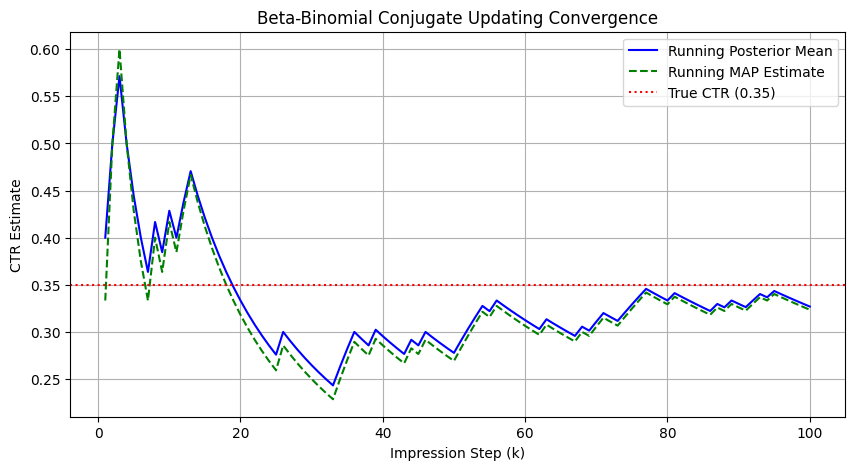

In [2]:
# Task 5 & 6: Performance Tracking and Convergence Analysis
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Parameters
np.random.seed(42)
true_ctr = 0.35
n_impressions = 100

# Generate Synthetic Dynamic Interactions
y_stream = np.random.binomial(1, true_ctr, n_impressions)

# Prior Hyperparameters
alpha_curr, beta_curr = 2, 2

bayes_means = []
map_estimates = []

for y in y_stream:
    alpha_curr += y
    beta_curr += (1 - y)

    # Point Estimates
    mean_val = alpha_curr / (alpha_curr + beta_curr)
    map_val = (alpha_curr - 1) / (alpha_curr + beta_curr - 2) if (alpha_curr > 1 and beta_curr > 1) else mean_val

    bayes_means.append(mean_val)
    map_estimates.append(map_val)

# Visualization of Convergence
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_impressions + 1), bayes_means, label='Running Posterior Mean', color='blue')
plt.plot(range(1, n_impressions + 1), map_estimates, label='Running MAP Estimate', color='green', linestyle='--')
plt.axhline(true_ctr, color='red', linestyle=':', label=f'True CTR ({true_ctr})')
plt.xlabel('Impression Step (k)')
plt.ylabel('CTR Estimate')
plt.title('Beta-Binomial Conjugate Updating Convergence')
plt.legend()
plt.grid(True)
plt.show()

# Section 3: Bayesian Estimations for Structural Health Monitoring via Bounded Grid Updates

## Task 1: Prior Belief Boundaries
* **Prior Distribution:** $\Theta \sim \text{Beta}(8, 1.5)$ over domain $\theta \in (0, 1]$.
* **Expected Prior Stiffness:**
  $$\mathbb{E}[\Theta^{(0)}] = \frac{\alpha_0}{\alpha_0 + \beta_0} = \frac{8}{8 + 1.5} = \frac{8}{9.5} \approx 0.842$$
* **Engineering Justification:** The distribution places high initial probability mass near $\theta = 1.0$, encoding the baseline prior belief that a newly deployed structural component is overwhelmingly likely to be healthy.

## Task 2: Structural Likelihood Formulation
Given sensor forward model $y_k = \theta K_{\text{nominal}} e^{\epsilon_k}$ with $\epsilon_k \sim \mathcal{N}(0, \sigma^2)$:
* **Single Likelihood Contribution:**
  $$L(y_k \mid \theta) = \frac{1}{\sqrt{2\pi} \sigma y_k} \exp\left( -\frac{(\ln(y_k) - \ln(\theta K_{\text{nominal}}))^2}{2\sigma^2} \right)$$
* **Joint Likelihood Function:**
  $$L(\mathbf{y}^{(k)} \mid \theta) = \prod_{i=1}^k \frac{1}{\sqrt{2\pi} \sigma y_i} \exp\left( -\frac{(\ln(y_i) - \ln(\theta K_{\text{nominal}}))^2}{2\sigma^2} \right)$$

## Task 3: Non-Conjugate Grid Update Formulation
A closed-form solution does not exist because combining a Beta density kernel $\theta^{\alpha-1}(1-\theta)^{\beta-1}$ with a log-normal likelihood produces an intractable, non-conjugate mathematical product.
* **Recursive Posterior Update:**
  $$f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)}) \propto L(y_k \mid \theta) \cdot f_{\Theta \mid \mathbf{Y}^{(k-1)}}(\theta \mid \mathbf{y}^{(k-1)})$$

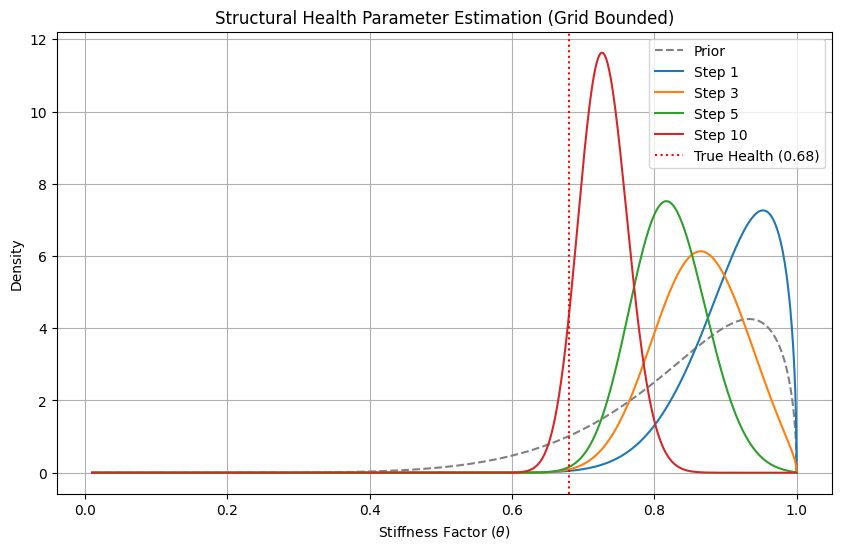

In [3]:
# Task 4, 5 & 6: Algorithmic Grid Approximation and Normalization
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Grid Setup
theta_grid = np.linspace(0.01, 1.0, 1000)
alpha_prior, beta_prior = 8.0, 1.5

# Prior Density
prior = beta.pdf(theta_grid, alpha_prior, beta_prior)
prior /= np.trapezoid(prior, theta_grid)

# Sensor Properties
K_nominal = 100.0
sigma = 0.15
true_health = 0.68

# Generate Synthetic Sensor Measurements
np.random.seed(101)
n_readings = 10
sensor_readings = true_health * K_nominal * np.exp(np.random.normal(0, sigma, n_readings))

posterior = prior.copy()
bayes_means = []

plt.figure(figsize=(10, 6))
plt.plot(theta_grid, prior, label="Prior", linestyle="--", color="gray")

for k, y in enumerate(sensor_readings, 1):
    # Log-normal likelihood computation
    mu_log = np.log(theta_grid * K_nominal)
    likelihood = (1 / (np.sqrt(2 * np.pi) * sigma * y)) * np.exp(-((np.log(y) - mu_log)**2) / (2 * sigma**2))

    # Update and Normalize
    unnorm_post = posterior * likelihood
    posterior = unnorm_post / np.trapezoid(unnorm_post, theta_grid)

    mean_val = np.trapezoid(theta_grid * posterior, theta_grid)
    bayes_means.append(mean_val)

    if k in [1, 3, 5, 10]:
        plt.plot(theta_grid, posterior, label=f"Step {k}")

plt.axvline(true_health, color='red', linestyle=':', label=f'True Health ({true_health})')
plt.title("Structural Health Parameter Estimation (Grid Bounded)")
plt.xlabel(r"Stiffness Factor ($\theta$)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

# Section 4: Gaussian Mixture Clustering as Conditional Updating

## Part 1: Deriving the Marginal Density
Using the Law of Total Probability over latent cluster indicator $C_i \in \{1, \dots, K\}$:
$$p(x_i) = \sum_{k=1}^K P(X_i = x_i \mid C_i = k) P(C_i = k) = \sum_{k=1}^K \phi_k \mathcal{N}(x_i \mid \mu_k, \Sigma_k)$$

## Part 2: Deriving the Posterior Cluster Probability (Responsibility)
Applying Bayes' Rule:
$$\gamma_{ik} = P(C_i = k \mid X_i = x_i) = \frac{\phi_k \mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_{j=1}^K \phi_j \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}$$

## Part 3: One-Hot Encoding of Latent Variables
For $Z_{ik} \in \{0, 1\}$:
$$\mathbb{E}[Z_{ik} \mid X_i = x_i] = 1 \cdot P(Z_{ik}=1 \mid X_i=x_i) + 0 \cdot P(Z_{ik}=0 \mid X_i=x_i) = P(C_i = k \mid X_i = x_i) = \gamma_{ik}$$

## Part 4: Soft Assignment vs. Hard Clustering
* **Soft Clustering ($\mathbb{E}[Z_i \mid X_i = x_i]$):** Assigns a continuous probability distribution across all clusters, maintaining classification uncertainty along cluster boundaries.
* **Hard Clustering ($\hat{C}_i = \arg\max_k \gamma_{ik}$):** Makes a deterministic "winner-take-all" assignment to the single most probable cluster index, discarding boundary ambiguity.

## Part 5: Conditional Expectation of Observation Given Cluster
* **Derivation:** $\mathbb{E}[X_i \mid C_i = k] = \int x_i \mathcal{N}(x_i \mid \mu_k, \Sigma_k) dx_i = \mu_k$.
* **Interpretation:** $\mu_k$ represents the center of mass (mean location) of cluster $k$.

## Part 6: Complete-Data Log-Likelihood
$$\ell_c = \ln p(\mathbf{x}, \mathbf{z}) = \sum_{i=1}^n \sum_{k=1}^K z_{ik} \left[ \ln \phi_k + \ln \mathcal{N}(x_i \mid \mu_k, \Sigma_k) \right]$$

## Part 7: The EM Interpretation
The E-step replaces hidden indicators $z_{ik}$ with conditional expectations $\gamma_{ik} = \mathbb{E}[Z_{ik} \mid X_i = x_i]$, forming the $Q$-function:
$$Q(\theta, \theta^{(\text{old})}) = \sum_{i=1}^n \sum_{k=1}^K \gamma_{ik} \left[ \ln \phi_k + \ln \mathcal{N}(x_i \mid \mu_k, \Sigma_k) \right]$$

## Part 8: Parameter Updates (M-Step)
* $N_k = \sum_{i=1}^n \gamma_{ik}$
* $\phi_k^{\text{new}} = \frac{N_k}{n}$
* $\mu_k^{\text{new}} = \frac{1}{N_k} \sum_{i=1}^n \gamma_{ik} x_i$
* $\Sigma_k^{\text{new}} = \frac{1}{N_k} \sum_{i=1}^n \gamma_{ik} (x_i - \mu_k^{\text{new}})(x_i - \mu_k^{\text{new}})^T$

In [4]:
# Part 10: Computational Simulation and Pipeline
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Generate Synthetic Financial Data
np.random.seed(42)
n_samples = 600
c1 = np.random.multivariate_normal([2, 2], [[1, 0.5], [0.5, 1]], 200)
c2 = np.random.multivariate_normal([-2, -2], [[1.5, -0.3], [-0.3, 0.8]], 200)
c3 = np.random.multivariate_normal([3, -3], [[0.5, 0], [0, 0.5]], 200)

X = np.vstack([c1, c2, c3])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into Train and Test sets
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

# Fit GMM via EM algorithm
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_train)

# Evaluate performance on test set
train_score = gmm.score(X_train)
test_score = gmm.score(X_test)

print(f"Train Log-Likelihood: {train_score:.4f}")
print(f"Test Log-Likelihood:  {test_score:.4f}")

# Compute responsibilities (soft assignments) for test set
responsibilities = gmm.predict_proba(X_test)
print("Sample Soft Assignment Responsibilities (First 5 test points):\n", responsibilities[:5])

Train Log-Likelihood: -1.9000
Test Log-Likelihood:  -1.9912
Sample Soft Assignment Responsibilities (First 5 test points):
 [[6.30261324e-01 1.34681192e-02 3.56270556e-01]
 [2.61822551e-05 9.99973818e-01 2.58392959e-14]
 [1.01291044e-04 9.99898709e-01 2.60811895e-11]
 [6.25444365e-08 3.44995943e-08 9.99999903e-01]
 [3.30774459e-10 6.17282247e-12 1.00000000e+00]]
